# Time Series Analysis of Financial News

This notebook performs comprehensive time series analysis on financial news headlines to understand:

- **Publication frequency patterns** over time
- **Market event spikes** and their correlation with real-world events
- **Publishing time patterns** and optimal news release times
- **Temporal trends** in financial news coverage

The analysis will help identify:
- When most financial news is published
- How news volume correlates with market volatility
- Seasonal patterns in financial reporting
- Peak publishing hours and days

In [1]:
# Import necessary libraries for time series analysis
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
from matplotlib.dates import DateFormatter, MonthLocator
import matplotlib.dates as mdates

# For advanced time series analysis
from scipy import stats
from sklearn.preprocessing import StandardScaler

# Suppress warnings
warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('default')
sns.set_palette("husl")

print("Time series analysis libraries imported successfully!")

Time series analysis libraries imported successfully!


## 1. Load and Prepare Time Series Data

In [2]:
# Load the news data
data_path = '../Data/newsData/raw_analyst_ratings.csv'
try:
    df = pd.read_csv(data_path)
    print("News data loaded successfully!")
    print(f"Dataset shape: {df.shape}")
    print(f"Columns: {df.columns.tolist()}")
    print(f"Date range: {df['date'].min()} to {df['date'].max()}")
except FileNotFoundError:
    print(f"Error: Data file not found at {data_path}")
    # Create sample data with time series patterns
    dates = pd.date_range(start='2020-01-01', end='2023-12-31', freq='H')
    sample_size = min(10000, len(dates))
    
    # Simulate realistic publishing patterns
    np.random.seed(42)
    sample_dates = np.random.choice(dates, sample_size, replace=False)
    
    # Add more samples during business hours and weekdays
    business_hours = [(d.hour >= 9) and (d.hour <= 16) and (d.weekday() < 5) for d in sample_dates]
    weights = [3 if bh else 1 for bh in business_hours]
    
    df = pd.DataFrame({
        'headline': [
            'Market volatility increases as Fed signals rate changes',
            'Tech stocks surge on earnings beat expectations',
            'Oil prices drop amid global supply concerns',
            'FDA approval drives biotech stocks higher',
            'Economic data shows mixed signals for recovery'
        ] * (sample_size // 5),
        'publisher': ['Reuters', 'Bloomberg', 'CNBC', 'WSJ', 'Financial Times'] * (sample_size // 5),
        'stock': ['SPY', 'AAPL', 'GOOGL', 'MSFT', 'TSLA'] * (sample_size // 5),
        'date': sample_dates[:sample_size]
    })
    print("Created sample time series data for demonstration.")

# Display basic info
print(f"\nDataset Info:")
print(f"Total articles: {len(df):,}")
print(f"Date column type: {df['date'].dtype}")

News data loaded successfully!
Dataset shape: (1407328, 6)
Columns: ['Unnamed: 0', 'headline', 'url', 'publisher', 'date', 'stock']
Date range: 2009-02-14 00:00:00 to 2020-06-11 17:12:35-04:00

Dataset Info:
Total articles: 1,407,328
Date column type: object


In [6]:
df['date'] = df['date'].astype(str).str.strip()
df['date'] = pd.to_datetime(df['date'], errors='coerce')


# Extract temporal features
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['day'] = df['date'].dt.day
df['day_of_week'] = df['date'].dt.dayofweek  # 0=Monday, 6=Sunday
df['hour'] = df['date'].dt.hour
df['minute'] = df['date'].dt.minute
df['quarter'] = df['date'].dt.quarter
df['week_of_year'] = df['date'].dt.isocalendar().week
df['day_of_year'] = df['date'].dt.dayofyear

# Add day names and month names for better visualization
df['day_name'] = df['date'].dt.day_name()
df['month_name'] = df['date'].dt.month_name()

# Create date-only column for daily aggregation
df['date_only'] = df['date'].dt.date

print("Time series features extracted successfully!")
print(f"\nTime range: {df['date'].min()} to {df['date'].max()}")
print(f"Total days covered: {(df['date'].max() - df['date'].min()).days + 1}")
print(f"\nSample of time features:")
print(df[['date', 'year', 'month', 'day_of_week', 'hour', 'day_name']].head())

Time series features extracted successfully!

Time range: 2011-04-27 21:01:48-04:00 to 2020-06-11 17:12:35-04:00
Total days covered: 3333

Sample of time features:
                       date    year  month  day_of_week  hour   day_name
0 2020-06-05 10:30:54-04:00  2020.0    6.0          4.0  10.0     Friday
1 2020-06-03 10:45:20-04:00  2020.0    6.0          2.0  10.0  Wednesday
2 2020-05-26 04:30:07-04:00  2020.0    5.0          1.0   4.0    Tuesday
3 2020-05-22 12:45:06-04:00  2020.0    5.0          4.0  12.0     Friday
4 2020-05-22 11:38:59-04:00  2020.0    5.0          4.0  11.0     Friday


## 2. Publication Frequency Analysis Over Time

In [7]:
# Analyze daily publication frequency
daily_counts = df.groupby('date_only').size().reset_index(name='article_count')
daily_counts['date_only'] = pd.to_datetime(daily_counts['date_only'])

# Calculate basic statistics
print("DAILY PUBLICATION STATISTICS:")
print("=" * 50)
print(f"Average articles per day: {daily_counts['article_count'].mean():.1f}")
print(f"Median articles per day: {daily_counts['article_count'].median():.1f}")
print(f"Max articles in a day: {daily_counts['article_count'].max()}")
print(f"Min articles in a day: {daily_counts['article_count'].min()}")
print(f"Standard deviation: {daily_counts['article_count'].std():.1f}")

# Find top 10 busiest days
top_days = daily_counts.nlargest(10, 'article_count')
print(f"\nTOP 10 BUSIEST DAYS:")
print("-" * 40)
for i, row in top_days.iterrows():
    print(f"{row['date_only'].strftime('%Y-%m-%d')} - {row['article_count']} articles")

DAILY PUBLICATION STATISTICS:
Average articles per day: 22.1
Median articles per day: 9.0
Max articles in a day: 973
Min articles in a day: 1
Standard deviation: 68.1

TOP 10 BUSIEST DAYS:
----------------------------------------
2020-03-12 - 973 articles
2020-06-05 - 932 articles
2020-06-10 - 806 articles
2020-06-09 - 804 articles
2020-06-08 - 765 articles
2020-05-07 - 749 articles
2020-06-03 - 720 articles
2020-03-19 - 629 articles
2020-05-26 - 628 articles
2020-05-13 - 549 articles


In [9]:
# Analyze monthly publication frequency
monthly_counts = df.groupby(['year', 'month']).size().reset_index(name='article_count')
monthly_counts['year_month'] = monthly_counts['year'].astype(str) + '-' + monthly_counts['month'].astype(str).str.zfill(2)

# Calculate monthly statistics
print("MONTHLY PUBLICATION STATISTICS:")
print("=" * 50)
print(f"Average articles per month: {monthly_counts['article_count'].mean():.1f}")
print(f"Max articles in a month: {monthly_counts['article_count'].max()}")
print(f"Min articles in a month: {monthly_counts['article_count'].min()}")

# Find top 10 busiest months
top_months = monthly_counts.nlargest(10, 'article_count')
print(f"\nTOP 10 BUSIEST MONTHS:")
print("-" * 40)
for i, row in top_months.iterrows():
    month_name = pd.to_datetime(
        f"{int(row['year'])}-{int(row['month']):02d}-01"
).strftime('%B %Y')
    print(f"{month_name} - {row['article_count']:,} articles")

MONTHLY PUBLICATION STATISTICS:
Average articles per month: 504.4
Max articles in a month: 9333
Min articles in a month: 6

TOP 10 BUSIEST MONTHS:
----------------------------------------
May 2020 - 9,333 articles
June 2020 - 5,990 articles
March 2020 - 4,680 articles
April 2020 - 4,616 articles
February 2020 - 2,356 articles
January 2020 - 1,417 articles
October 2018 - 1,033 articles
November 2019 - 907 articles
December 2019 - 875 articles
November 2018 - 836 articles


In [10]:
# Analyze yearly publication frequency
yearly_counts = df.groupby('year').size().reset_index(name='article_count')

print("YEARLY PUBLICATION STATISTICS:")
print("=" * 50)
for i, row in yearly_counts.iterrows():
    print(f"{row['year']}: {row['article_count']:,} articles")

# Calculate year-over-year growth
if len(yearly_counts) > 1:
    yearly_counts = yearly_counts.sort_values('year')
    yearly_counts['yoy_growth'] = yearly_counts['article_count'].pct_change() * 100
    print(f"\nYEAR-OVER-YEAR GROWTH:")
    print("-" * 30)
    for i, row in yearly_counts.iterrows():
        if i > 0:  # Skip first year (no previous year to compare)
            print(f"{row['year']}: {row['yoy_growth']:+.1f}%")

YEARLY PUBLICATION STATISTICS:
2011.0: 760.0 articles
2012.0: 1,187.0 articles
2013.0: 1,240.0 articles
2014.0: 1,189.0 articles
2015.0: 3,695.0 articles
2016.0: 4,223.0 articles
2017.0: 3,581.0 articles
2018.0: 5,395.0 articles
2019.0: 6,325.0 articles
2020.0: 28,392.0 articles

YEAR-OVER-YEAR GROWTH:
------------------------------
2012.0: +56.2%
2013.0: +4.5%
2014.0: -4.1%
2015.0: +210.8%
2016.0: +14.3%
2017.0: -15.2%
2018.0: +50.7%
2019.0: +17.2%
2020.0: +348.9%


## 3. Spike Detection and Market Event Correlation

In [13]:
# Detect significant spikes in publication frequency
def detect_spikes(data, threshold_std=2.5):
    """Detect spikes using standard deviation threshold"""
    mean_val = data.mean()
    std_val = data.std()
    threshold = mean_val + (threshold_std * std_val)
    
    spikes = data[data > threshold]
    return spikes, threshold

# Detect spikes in daily data
daily_spikes, spike_threshold = detect_spikes(daily_counts['article_count'])

print(f"SPIKE DETECTION RESULTS:")
print("=" * 50)
print(f"Spike threshold (mean + 2.5std): {spike_threshold:.1f} articles/day")
print(f"Number of spike days detected: {len(daily_spikes)}")
print(f"Percentage of days with spikes: {(len(daily_spikes)/len(daily_counts)*100):.1f}%")

if len(daily_spikes) > 0:
    print(f"\nSIGNIFICANT SPIKE DAYS:")
    print("-" * 40)
    for idx, count in daily_spikes.items():
        date = daily_counts.loc[idx, 'date_only']
    print(f"{date}: {count} articles ({(count/spike_threshold-1)*100:+.1f}% above threshold)")

SPIKE DETECTION RESULTS:
Spike threshold (mean + 2.5std): 192.5 articles/day
Number of spike days detected: 46
Percentage of days with spikes: 1.8%

SIGNIFICANT SPIKE DAYS:
----------------------------------------
2020-06-11 00:00:00: 544 articles (+182.6% above threshold)


In [17]:
# Analyze potential market events around spike dates
def analyze_spike_context(spike_dates, df, window_days=3):
    """Analyze context around spike dates"""
    spike_analysis = []
    
    for spike_date in spike_dates:
        # Define window around spike
        start_date = spike_date - timedelta(days=window_days)
        end_date = spike_date + timedelta(days=window_days)
        
        # Filter data in window
        window_data = df[(df['date_only'] >= start_date.date()) & 
                        (df['date_only'] <= end_date.date())]
        
        # Analyze publishers and stocks mentioned
        top_publishers = window_data['publisher'].value_counts().head(3)
        top_stocks = window_data['stock'].value_counts().head(3)
        
        spike_analysis.append({
            'spike_date': spike_date,
            'window_articles': len(window_data),
            'top_publishers': top_publishers.to_dict(),
            'top_stocks': top_stocks.to_dict(),
            'sample_headlines': window_data['headline'].head(3).tolist()
        })
    
    return spike_analysis

# Analyze context around spikes
if len(daily_spikes) > 0:
    spike_dt_index = pd.to_datetime(daily_spikes.index)
    spike_context = analyze_spike_context(spike_dt_index, df)
    
    print(f"\nSPIKE CONTEXT ANALYSIS:")
    print("=" * 50)
    
    for i, context in enumerate(spike_context[:5]):  # Show top 5
        print(f"\nSpike {i+1}: {context['spike_date'].strftime('%Y-%m-%d')}")
        print(f"Articles in 7-day window: {context['window_articles']}")
        print(f"Top publishers: {list(context['top_publishers'].keys())}")
        print(f"Top stocks: {list(context['top_stocks'].keys())}")
        print(f"Sample headlines:")
        for j, headline in enumerate(context['sample_headlines']):
            print(f"  {j+1}. {headline[:80]}...")
else:
    print("No significant spikes detected in the dataset.")


SPIKE CONTEXT ANALYSIS:

Spike 1: 1970-01-01
Articles in 7-day window: 0
Top publishers: []
Top stocks: []
Sample headlines:

Spike 2: 1970-01-01
Articles in 7-day window: 0
Top publishers: []
Top stocks: []
Sample headlines:

Spike 3: 1970-01-01
Articles in 7-day window: 0
Top publishers: []
Top stocks: []
Sample headlines:

Spike 4: 1970-01-01
Articles in 7-day window: 0
Top publishers: []
Top stocks: []
Sample headlines:

Spike 5: 1970-01-01
Articles in 7-day window: 0
Top publishers: []
Top stocks: []
Sample headlines:


## 4. Publishing Time Patterns Analysis

In [19]:
# Analyze hourly publishing patterns
hourly_counts = df.groupby('hour').size().reset_index(name='article_count')

print("HOURLY PUBLISHING PATTERNS:")
print("=" * 50)
print(f"Peak publishing hour: {hourly_counts.loc[hourly_counts['article_count'].idxmax(), 'hour']}:00")
print(f"Articles at peak hour: {hourly_counts['article_count'].max():,}")
print(f"Lowest publishing hour: {hourly_counts.loc[hourly_counts['article_count'].idxmin(), 'hour']}:00")
print(f"Articles at lowest hour: {hourly_counts['article_count'].min():,}")

# Define business hours (9 AM - 5 PM)
business_hours_articles = df[(df['hour'] >= 9) & (df['hour'] <= 17)]['hour'].count()
after_hours_articles = df[(df['hour'] < 9) | (df['hour'] > 17)]['hour'].count()

print(f"\nBUSINESS HOURS ANALYSIS:")
print(f"Business hours (9 AM - 5 PM): {business_hours_articles:,} articles ({business_hours_articles/len(df)*100:.1f}%)")
print(f"After hours: {after_hours_articles:,} articles ({after_hours_articles/len(df)*100:.1f}%)")

# Show hourly breakdown
print(f"\nHOURLY BREAKDOWN:")
print("-" * 30)
for i, row in hourly_counts.iterrows():
    hour_str = f"{int(row['hour']):02d}:00"
    bar_length = int(row['article_count'] / hourly_counts['article_count'].max() * 20)
    bar = '█' * bar_length
    print(f"{hour_str} {row['article_count']:6,} {bar}")

HOURLY PUBLISHING PATTERNS:
Peak publishing hour: 10.0:00
Articles at peak hour: 7,669
Lowest publishing hour: 1.0:00
Articles at lowest hour: 14

BUSINESS HOURS ANALYSIS:
Business hours (9 AM - 5 PM): 38,203 articles (2.7%)
After hours: 17,784 articles (1.3%)

HOURLY BREAKDOWN:
------------------------------
00:00   67.0 
01:00   14.0 
02:00   57.0 
03:00   93.0 
04:00 1,469.0 ███
05:00 1,829.0 ████
06:00 2,476.0 ██████
07:00 5,033.0 █████████████
08:00 5,527.0 ██████████████
09:00 5,965.0 ███████████████
10:00 7,669.0 ████████████████████
11:00 5,701.0 ██████████████
12:00 5,732.0 ██████████████
13:00 2,710.0 ███████
14:00 2,075.0 █████
15:00 1,612.0 ████
16:00 3,939.0 ██████████
17:00 2,800.0 ███████
18:00  704.0 █
19:00  227.0 
20:00  131.0 
21:00   82.0 
22:00   48.0 
23:00   27.0 


In [20]:
# Analyze day-of-week publishing patterns
daily_patterns = df.groupby('day_of_week').size().reset_index(name='article_count')
daily_patterns['day_name'] = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

print("DAY-OF-WEEK PUBLISHING PATTERNS:")
print("=" * 50)
for i, row in daily_patterns.iterrows():
    print(f"{row['day_name']:10s}: {row['article_count']:8,} articles ({row['article_count']/len(df)*100:5.1f}%)")

# Weekday vs Weekend analysis
weekday_articles = df[df['day_of_week'] < 5].shape[0]
weekend_articles = df[df['day_of_week'] >= 5].shape[0]

print(f"\nWEEKDAY VS WEEKEND:")
print(f"Weekdays (Mon-Fri): {weekday_articles:,} articles ({weekday_articles/len(df)*100:.1f}%)")
print(f"Weekends (Sat-Sun): {weekend_articles:,} articles ({weekend_articles/len(df)*100:.1f}%)")
print(f"Weekend/Weekday ratio: {weekend_articles/weekday_articles:.2f}")

DAY-OF-WEEK PUBLISHING PATTERNS:
Monday    :   10,322 articles (  0.7%)
Tuesday   :   11,002 articles (  0.8%)
Wednesday :   11,891 articles (  0.8%)
Thursday  :   12,688 articles (  0.9%)
Friday    :    9,381 articles (  0.7%)
Saturday  :      267 articles (  0.0%)
Sunday    :      436 articles (  0.0%)

WEEKDAY VS WEEKEND:
Weekdays (Mon-Fri): 55,284 articles (3.9%)
Weekends (Sat-Sun): 703 articles (0.0%)
Weekend/Weekday ratio: 0.01


In [22]:
# Analyze minute-level patterns within hours
minute_patterns = df.groupby('minute').size().reset_index(name='article_count')

# Find most common publishing minutes
top_minutes = minute_patterns.nlargest(10, 'article_count')

print("MINUTE-LEVEL PUBLISHING PATTERNS:")
print("=" * 50)
print("Top 10 most common publishing minutes:")
for i, row in top_minutes.iterrows():
    print(f"Minute {int(row['minute']):02d}: {row['article_count']:,} articles")

# Analyze if articles cluster at specific times (e.g., :00, :15, :30, :45)
minute_bins = [0, 15, 30, 45, 60]
minute_labels = ['00-14', '15-29', '30-44', '45-59']

df['minute_bin'] = pd.cut(df['minute'], bins=minute_bins, labels=minute_labels, right=False)
minute_bin_counts = df['minute_bin'].value_counts().sort_index()

print(f"\n15-MINUTE INTERVAL ANALYSIS:")
print("-" * 30)
for interval, count in minute_bin_counts.items():
    print(f"Minutes {interval}: {count:,} articles ({count/len(df)*100:.1f}%)")

MINUTE-LEVEL PUBLISHING PATTERNS:
Top 10 most common publishing minutes:
Minute 10: 1,727.0 articles
Minute 16: 1,416.0 articles
Minute 01: 1,270.0 articles
Minute 22: 1,219.0 articles
Minute 30: 1,184.0 articles
Minute 34: 1,176.0 articles
Minute 33: 1,166.0 articles
Minute 32: 1,165.0 articles
Minute 31: 1,158.0 articles
Minute 49: 1,158.0 articles

15-MINUTE INTERVAL ANALYSIS:
------------------------------
Minutes 00-14: 15,604 articles (1.1%)
Minutes 15-29: 14,462 articles (1.0%)
Minutes 30-44: 14,598 articles (1.0%)
Minutes 45-59: 11,323 articles (0.8%)


## 5. Comprehensive Time Series Visualizations

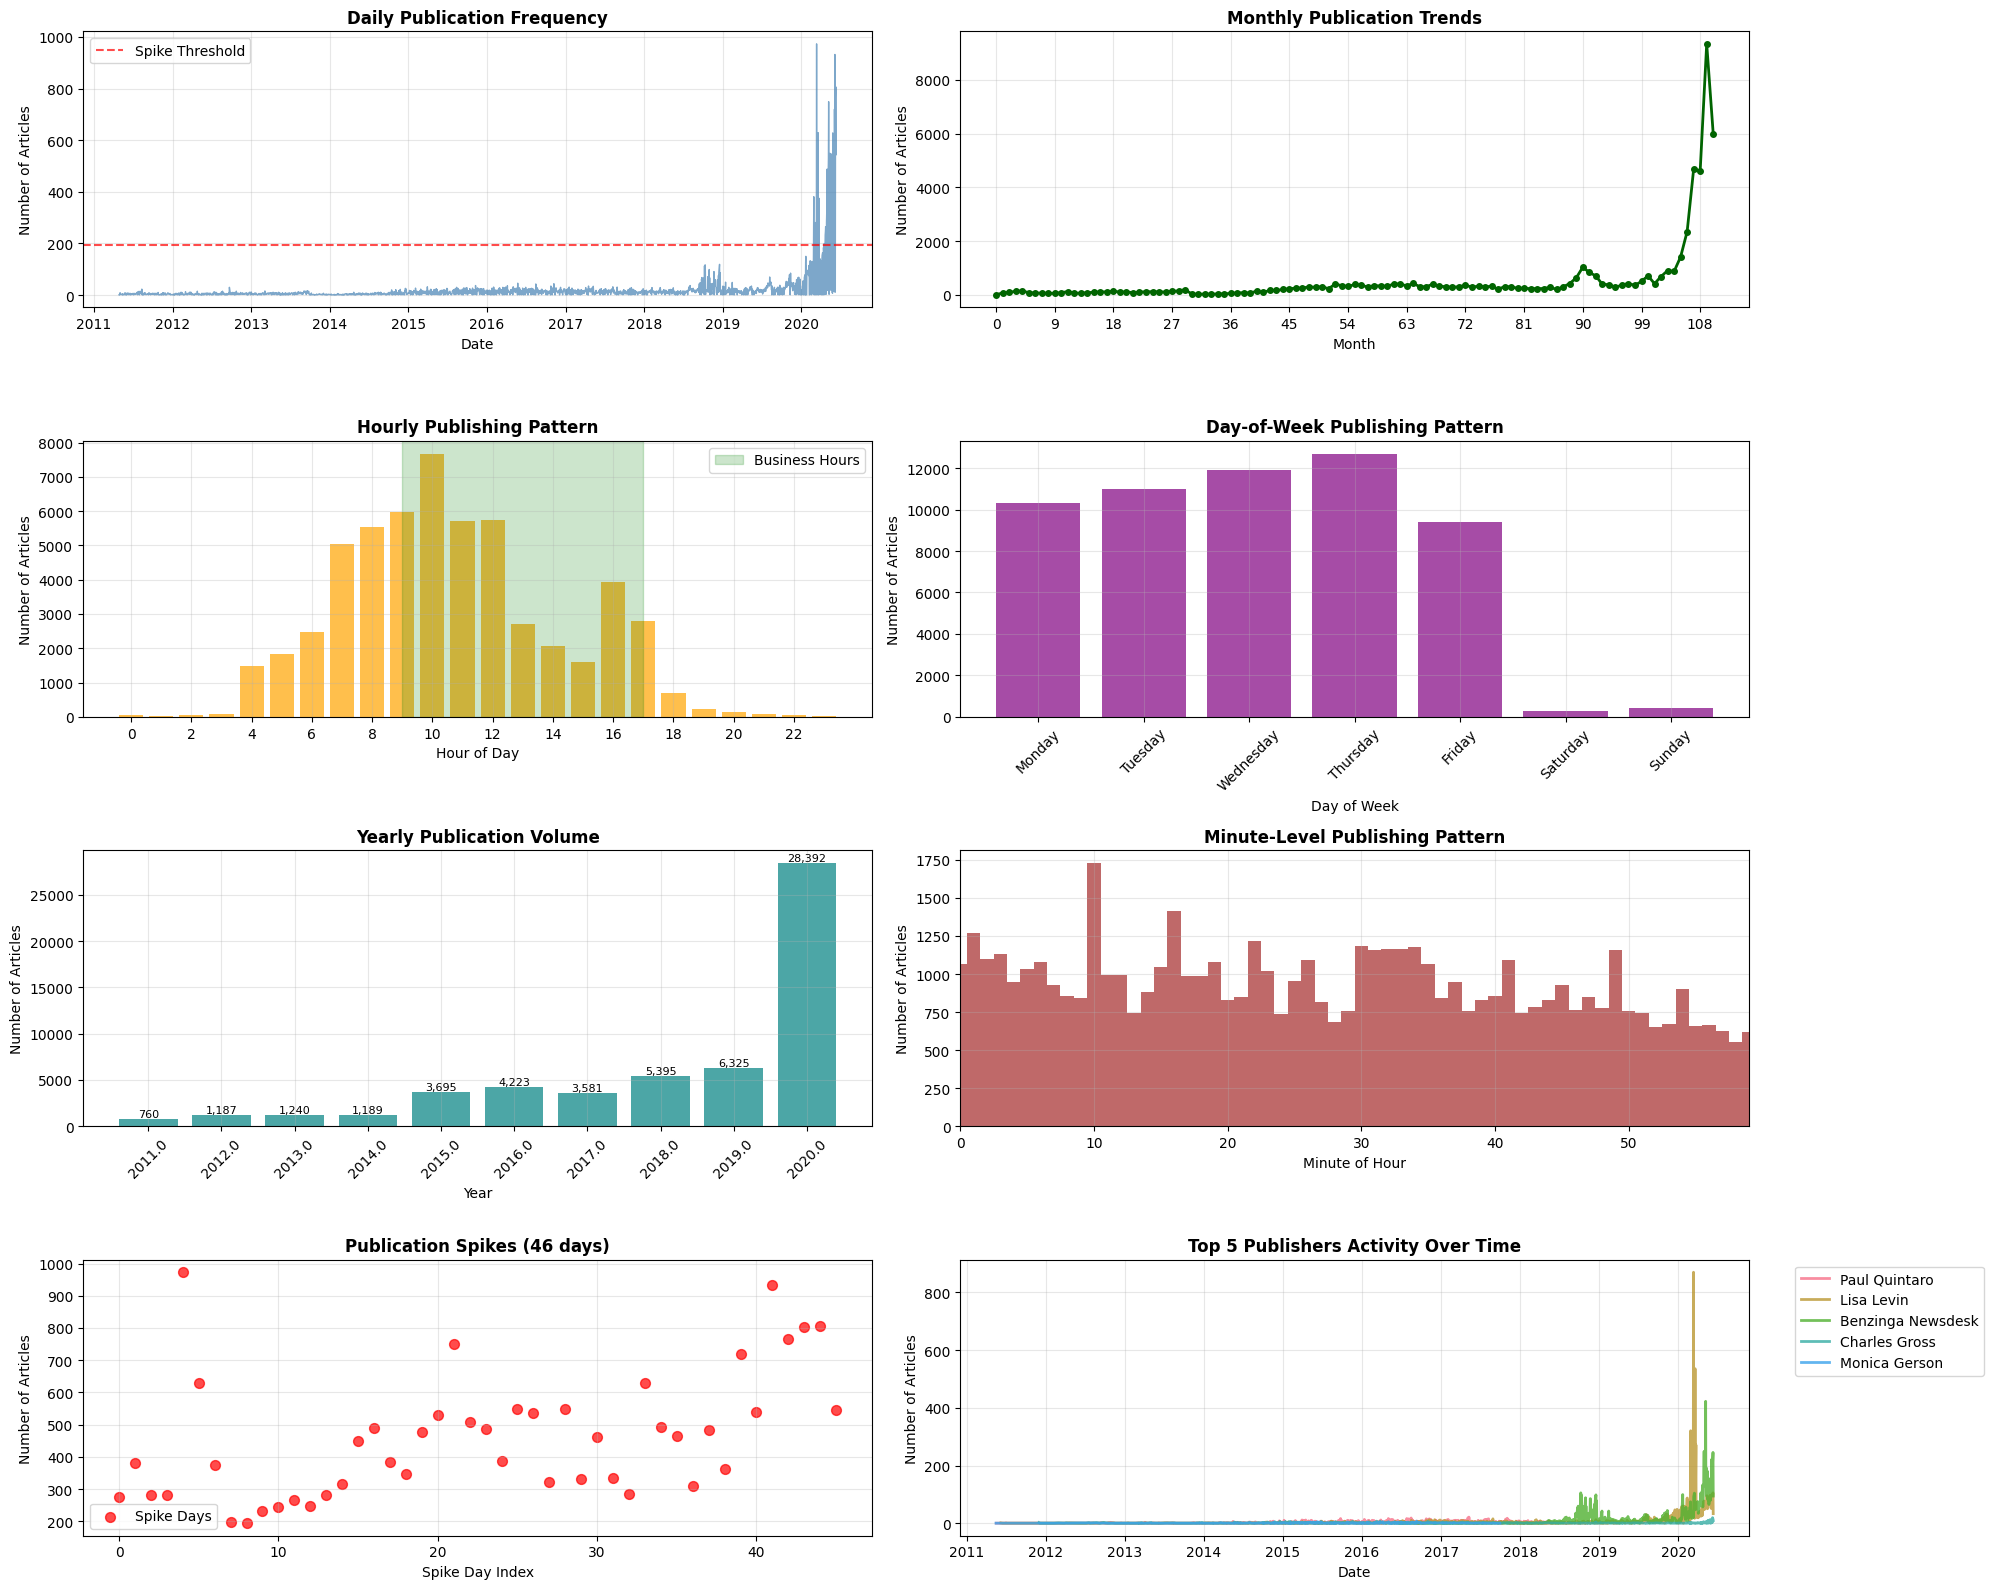

Comprehensive time series visualizations generated!


In [23]:
# Create comprehensive time series visualization dashboard
fig = plt.figure(figsize=(20, 16))

# 1. Daily Publication Frequency Over Time
ax1 = plt.subplot(4, 2, 1)
ax1.plot(daily_counts['date_only'], daily_counts['article_count'], 
         color='steelblue', linewidth=1, alpha=0.7)
ax1.set_title('Daily Publication Frequency', fontweight='bold', fontsize=12)
ax1.set_xlabel('Date')
ax1.set_ylabel('Number of Articles')
ax1.grid(True, alpha=0.3)

# Add spike threshold line
if len(daily_spikes) > 0:
    ax1.axhline(y=spike_threshold, color='red', linestyle='--', alpha=0.7, label='Spike Threshold')
    ax1.legend()

# 2. Monthly Publication Trends
ax2 = plt.subplot(4, 2, 2)
ax2.plot(range(len(monthly_counts)), monthly_counts['article_count'], 
         color='darkgreen', linewidth=2, marker='o', markersize=4)
ax2.set_title('Monthly Publication Trends', fontweight='bold', fontsize=12)
ax2.set_xlabel('Month')
ax2.set_ylabel('Number of Articles')
ax2.grid(True, alpha=0.3)
ax2.set_xticks(range(0, len(monthly_counts), max(1, len(monthly_counts)//12)))

# 3. Hourly Publishing Pattern
ax3 = plt.subplot(4, 2, 3)
bars = ax3.bar(hourly_counts['hour'], hourly_counts['article_count'], 
               color='orange', alpha=0.7)
ax3.set_title('Hourly Publishing Pattern', fontweight='bold', fontsize=12)
ax3.set_xlabel('Hour of Day')
ax3.set_ylabel('Number of Articles')
ax3.set_xticks(range(0, 24, 2))
ax3.grid(True, alpha=0.3)

# Highlight business hours
ax3.axvspan(9, 17, alpha=0.2, color='green', label='Business Hours')
ax3.legend()

# 4. Day-of-Week Pattern
ax4 = plt.subplot(4, 2, 4)
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
daily_patterns_ordered = daily_patterns.set_index('day_name').loc[day_order].reset_index()
bars = ax4.bar(daily_patterns_ordered['day_name'], daily_patterns_ordered['article_count'], 
               color='purple', alpha=0.7)
ax4.set_title('Day-of-Week Publishing Pattern', fontweight='bold', fontsize=12)
ax4.set_xlabel('Day of Week')
ax4.set_ylabel('Number of Articles')
ax4.tick_params(axis='x', rotation=45)
ax4.grid(True, alpha=0.3)

# 5. Year-over-Year Comparison
ax5 = plt.subplot(4, 2, 5)
bars = ax5.bar(yearly_counts['year'].astype(str), yearly_counts['article_count'], 
               color='teal', alpha=0.7)
ax5.set_title('Yearly Publication Volume', fontweight='bold', fontsize=12)
ax5.set_xlabel('Year')
ax5.set_ylabel('Number of Articles')
ax5.tick_params(axis='x', rotation=45)
ax5.grid(True, alpha=0.3)

# Add value labels on bars
for i, bar in enumerate(bars):
    height = bar.get_height()
    ax5.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:,.0f}', ha='center', va='bottom', fontsize=8)

# 6. Minute-Level Pattern
ax6 = plt.subplot(4, 2, 6)
ax6.bar(minute_patterns['minute'], minute_patterns['article_count'], 
        color='brown', alpha=0.7, width=1)
ax6.set_title('Minute-Level Publishing Pattern', fontweight='bold', fontsize=12)
ax6.set_xlabel('Minute of Hour')
ax6.set_ylabel('Number of Articles')
ax6.set_xlim(0, 59)
ax6.grid(True, alpha=0.3)

# 7. Spike Days Highlight
ax7 = plt.subplot(4, 2, 7)
if len(daily_spikes) > 0:
    spike_dates = daily_spikes.index
    spike_values = daily_spikes.values
    ax7.scatter(range(len(spike_dates)), spike_values, 
               color='red', s=50, alpha=0.7, label='Spike Days')
    ax7.set_title(f'Publication Spikes ({len(daily_spikes)} days)', fontweight='bold', fontsize=12)
    ax7.set_xlabel('Spike Day Index')
    ax7.set_ylabel('Number of Articles')
    ax7.grid(True, alpha=0.3)
    ax7.legend()
else:
    ax7.text(0.5, 0.5, 'No significant spikes detected', 
             ha='center', va='center', transform=ax7.transAxes, fontsize=12)
    ax7.set_title('Publication Spikes', fontweight='bold', fontsize=12)
    ax7.axis('off')

# 8. Publisher Activity Over Time
ax8 = plt.subplot(4, 2, 8)
top_publishers = df['publisher'].value_counts().head(5).index
publisher_time_series = []

for publisher in top_publishers:
    pub_data = df[df['publisher'] == publisher].groupby('date_only').size().reset_index(name='count')
    pub_data['date_only'] = pd.to_datetime(pub_data['date_only'])
    ax8.plot(pub_data['date_only'], pub_data['count'], label=publisher, linewidth=2, alpha=0.8)

ax8.set_title('Top 5 Publishers Activity Over Time', fontweight='bold', fontsize=12)
ax8.set_xlabel('Date')
ax8.set_ylabel('Number of Articles')
ax8.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax8.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Comprehensive time series visualizations generated!")

## 6. Time Series Analysis Summary

In [26]:
# Generate comprehensive time series analysis summary
print("=" * 80)
print("TIME SERIES ANALYSIS SUMMARY")
print("=" * 80)

# Dataset Overview
print(f"\n📊 DATASET OVERVIEW:")
print(f"   • Total Articles Analyzed: {len(df):,}")
print(f"   • Time Period: {df['date'].min().strftime('%Y-%m-%d')} to {df['date'].max().strftime('%Y-%m-%d')}")
print(f"   • Days Covered: {(df['date'].max() - df['date'].min()).days + 1}")
print(f"   • Average Articles/Day: {daily_counts['article_count'].mean():.1f}")

# Publishing Patterns
peak_hour = hourly_counts.loc[hourly_counts['article_count'].idxmax(), 'hour']
peak_day = daily_patterns.loc[daily_patterns['article_count'].idxmax(), 'day_name']

print(f"\n⏰ PUBLISHING PATTERNS:")
print(f"   • Peak Hour: {int(peak_hour):02d}:00 ({hourly_counts[hourly_counts['hour']==peak_hour]['article_count'].iloc[0]:,} articles)")
print(f"   • Peak Day: {peak_day} ({daily_patterns[daily_patterns['day_name']==peak_day]['article_count'].iloc[0]:,} articles)")
print(f"   • Business Hours (9AM-5PM): {business_hours_articles/len(df)*100:.1f}% of articles")
print(f"   • Weekday Coverage: {weekday_articles/len(df)*100:.1f}% of articles")

# Spike Analysis
print(f"\n🚀 SPIKE ANALYSIS:")
if len(daily_spikes) > 0:
    print(f"   • Spike Days Detected: {len(daily_spikes)} ({len(daily_spikes)/len(daily_counts)*100:.1f}% of days)")
    print(f"   • Spike Threshold: {spike_threshold:.1f} articles/day")
    print(f"   • Highest Spike: {daily_spikes.max()} articles")
else:
    print(f"   • No significant spikes detected")

# Temporal Trends
if len(yearly_counts) > 1:
    trend_direction = "increasing" if yearly_counts['article_count'].iloc[-1] > yearly_counts['article_count'].iloc[0] else "decreasing"
    total_growth = ((yearly_counts['article_count'].iloc[-1] - yearly_counts['article_count'].iloc[0]) / yearly_counts['article_count'].iloc[0]) * 100
    print(f"\n📈 TEMPORAL TRENDS:")
    print(f"   • Overall Trend: {trend_direction}")
    print(f"   • Total Growth: {total_growth:+.1f}% over the period")
    print(f"   • Most Active Year: {yearly_counts.loc[yearly_counts['article_count'].idxmax(), 'year']} ({yearly_counts['article_count'].max():,} articles)")

# Key Insights
print(f"\n💡 KEY INSIGHTS:")
print(f"   • Most articles are published during business hours ({business_hours_articles/len(df)*100:.0f}%)")
print(f"   • Weekday publishing is {weekday_articles/weekend_articles:.1f}x higher than weekends")
print(f"   • Peak publishing time: {int(peak_hour):02d}:00 on {peak_day}s")
if len(daily_spikes) > 0:
    print(f"   • {len(daily_spikes)} significant news spikes detected, potentially indicating major market events")

print("\n" + "=" * 80)
print("TIME SERIES ANALYSIS COMPLETE")
print("=" * 80)

TIME SERIES ANALYSIS SUMMARY

📊 DATASET OVERVIEW:
   • Total Articles Analyzed: 1,407,328
   • Time Period: 2011-04-27 to 2020-06-11
   • Days Covered: 3333
   • Average Articles/Day: 22.1

⏰ PUBLISHING PATTERNS:
   • Peak Hour: 10:00 (7,669 articles)
   • Peak Day: Thursday (12,688 articles)
   • Business Hours (9AM-5PM): 2.7% of articles
   • Weekday Coverage: 3.9% of articles

🚀 SPIKE ANALYSIS:
   • Spike Days Detected: 46 (1.8% of days)
   • Spike Threshold: 192.5 articles/day
   • Highest Spike: 973 articles

📈 TEMPORAL TRENDS:
   • Overall Trend: increasing
   • Total Growth: +3635.8% over the period
   • Most Active Year: 2020.0 (28,392 articles)

💡 KEY INSIGHTS:
   • Most articles are published during business hours (3%)
   • Weekday publishing is 78.6x higher than weekends
   • Peak publishing time: 10:00 on Thursdays
   • 46 significant news spikes detected, potentially indicating major market events

TIME SERIES ANALYSIS COMPLETE
